<a href="https://colab.research.google.com/github/R452h/Customer-churn-and-retension-analysis/blob/main/RaoDo_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas psycopg2-binary matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 19.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

customers = pd.read_csv("customers.csv")
subscriptions = pd.read_csv("subscriptions.csv")
plans = pd.read_csv("plans.csv")
tickets = pd.read_csv("tickets.csv")

In [5]:
print(customers.head())
print(subscriptions.head())
print(plans.head())
print(tickets.head())

   customer_id    company_name       industry company_size country_code  \
0            1   Rush Platform     E-commerce        small           FR   
1            2       TrekStack  Manufacturing        small           CA   
2            3      Wave Group      Education   enterprise           US   
3            4    KeenSoftware     Technology        large           GB   
4            5  QuestAnalytics      Logistics        large           US   

     country_name          timezone                contact_email  \
0          France      Europe/Paris       michael.baker@corp.net   
1          Canada   America/Toronto  emily.moore+work@startup.co   
2   United States  America/New_York  olga.robinson@wavegroup.com   
3  United Kingdom     Europe/London     lars.jackson@outlook.com   
4   United States   America/Chicago       joshua.green@yahoo.com   

    contact_name signup_date signup_source  is_active           churned_at  \
0  Michael Baker  2023-01-31       partner      False  2024-02

In [6]:
df = subscriptions.merge(customers, on="customer_id", how="left")
df = df.merge(plans, on="plan_id", how="left")

df.head()

,subscription_id,customer_id,plan_id,status,billing_cycle,start_date,end_date,mrr_usd,discount_pct,trial_end_date,...,updated_at,plan_name,plan_tier,monthly_price_usd,annual_price_usd,max_users,max_projects,storage_gb,is_active_y,created_at
0,1,1,1,cancelled,annual,2023-01-31,2023-04-20,0.00,15.0,NaN,...,2026-04-24 22:09:13.186774,Free,free,0.0,0.0,5.0,3.0,1,True,2026-04-24 22:09:13.186774
1,2,1,5,cancelled,annual,2023-04-20,2024-02-26,44.25,10.0,NaN,...,2026-04-24 22:09:13.186774,Professional Plus,professional,59.0,590.0,100.0,100.0,50,True,2026-04-24 22:09:13.186774
2,3,2,1,paused,monthly,2023-06-09,NaN,0.00,0.0,NaN,...,2026-04-24 22:09:13.186774,Free,free,0.0,0.0,5.0,3.0,1,True,2026-04-24 22:09:13.186774
3,4,3,1,active,annual,2023-10-28,NaN,0.00,20.0,NaN,...,2026-04-24 22:09:13.186774,Free,free,0.0,0.0,5.0,3.0,1,True,2026-04-24 22:09:13.186774
4,5,4,1,expired,annual,2024-04-09,2024-08-10,0.00,15.0,NaN,...,2026-04-24 22:09:13.186774,Free,free,0.0,0.0,5.0,3.0,1,True,2026-04-24 22:09:13.186774


In [7]:
df["revenue"] = df["monthly_price_usd"]

In [8]:
df["is_churned"] = df["churned_at"].notnull()

In [9]:
print("Total Revenue:", df["revenue"].sum())

Total Revenue: 58863.0


In [10]:
print("Churn Rate:", df["is_churned"].mean())

Churn Rate: 0.22717391304347825


In [11]:
plan_revenue = df.groupby("plan_name")["revenue"].sum()
print(plan_revenue)

plan_name
Enterprise           15543.0
Enterprise Custom     7164.0
Free                     0.0
Professional         11232.0
Professional Plus    15045.0
Starter               4692.0
Starter Plus          5187.0
Name: revenue, dtype: float64


In [12]:
top_customers = df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(10)
print(top_customers)

customer_id
952     357.0
440     357.0
919     317.0
872     317.0
953     298.0
616     298.0
909     297.0
1137    270.0
479     258.0
384     258.0
Name: revenue, dtype: float64


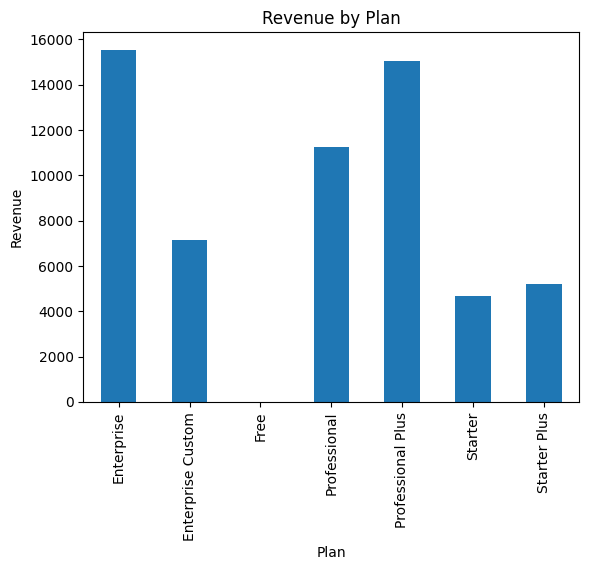

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plan_revenue.plot(kind="bar")
plt.title("Revenue by Plan")
plt.xlabel("Plan")
plt.ylabel("Revenue")
plt.show()

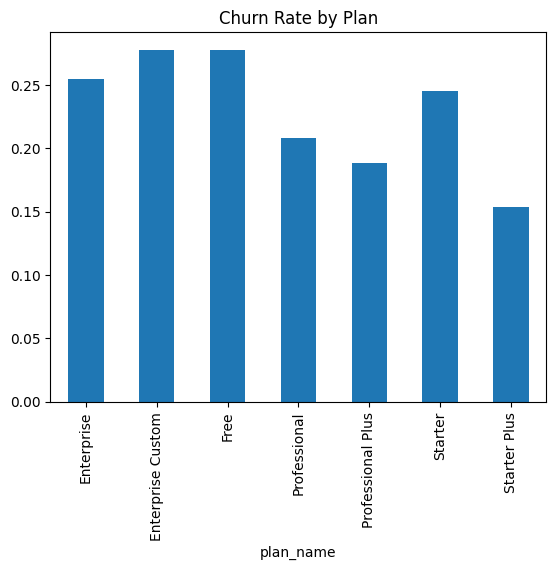

In [14]:
churn_by_plan = df.groupby("plan_name")["is_churned"].mean()

plt.figure()
churn_by_plan.plot(kind="bar")
plt.title("Churn Rate by Plan")
plt.show()

In [15]:
df.to_csv("final_dataset.csv", index=False)